# Notebook 1 — Data Cleaning & Preprocessing
## AI Blood Report Disease Diagnosis

**Purpose:** inspect the raw data, validate its structure, identify data-quality issues, prepare features and target, and export a cleaned dataset for the Random Forest notebook.

**Dataset:** `Training.csv` (provided with this notebook). Run cells from top to bottom. The notebook deliberately reports issues before applying any changes; it does not delete unusual clinical values automatically.

In [23]:
# If needed, install dependencies in your active environment:
# %pip install pandas numpy matplotlib seaborn scikit-learn

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
DATA_PATH = Path("Training.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("../Training.csv")
df_raw = pd.read_csv(DATA_PATH)
print("Dataset shape:", df_raw.shape)
display(df_raw.head())


Dataset shape: (598, 10)


,WBC,RBC,HGB,PLT,NEUT,LYMPH,MONO,EOS,BASO,Disease
0,3.7,4.90,15.6,275,1.96,1.32,0.17,0.25,0.03,3
1,7.0,5.12,13.5,386,3.33,3.05,0.53,0.09,0.06,13
2,5.0,4.67,13.3,211,2.00,2.09,0.26,0.61,0.03,11
3,6.9,4.80,15.0,224,3.77,1.75,0.58,0.70,0.05,11
4,4.2,5.31,16.0,224,2.18,1.49,0.20,0.29,0.03,3


## 1. Understand the dataset
Check column names, data types, summary statistics and the target distribution. `Disease` is the label the model learns to predict.

In [24]:
print("Columns:", df_raw.columns.tolist())
display(df_raw.info())
display(df_raw.describe(include="all").T)
display(df_raw["Disease"].value_counts().sort_index().rename("count").to_frame())


Columns: ['WBC', 'RBC', 'HGB', 'PLT', 'NEUT', 'LYMPH', 'MONO', 'EOS', 'BASO', 'Disease']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   WBC      598 non-null    float64
 1   RBC      598 non-null    float64
 2   HGB      598 non-null    float64
 3   PLT      598 non-null    int64  
 4   NEUT     598 non-null    float64
 5   LYMPH    598 non-null    float64
 6   MONO     598 non-null    float64
 7   EOS      598 non-null    float64
 8   BASO     598 non-null    float64
 9   Disease  598 non-null    int64  
dtypes: float64(8), int64(2)
memory usage: 46.8 KB


None

,count,mean,std,min,25%,50%,75%,max
WBC,598.0,5.973244,3.057761,1.30,4.6000,5.40,6.3750,33.00
RBC,598.0,5.289064,0.663620,3.00,4.8825,5.26,5.6675,7.77
HGB,598.0,14.202676,2.107081,4.00,13.2000,14.20,15.6000,18.40
PLT,598.0,259.555184,91.091351,21.00,213.2500,255.00,294.7500,654.00
NEUT,598.0,2.935452,1.267263,1.20,2.0925,2.54,3.3675,9.00
LYMPH,598.0,2.453612,0.861144,0.50,1.9500,2.28,2.8400,6.70
MONO,598.0,0.241003,0.261037,0.05,0.1400,0.18,0.2600,3.30
EOS,598.0,0.308763,0.411301,0.03,0.1100,0.22,0.3800,5.05
BASO,598.0,0.044876,0.053964,0.01,0.0200,0.03,0.0400,0.43
Disease,598.0,7.779264,4.917215,0.00,3.0000,9.00,13.0000,13.00


,count
Disease,
0,22
1,84
2,12
3,68
4,32
5,20
6,28
7,14
8,12


## 2. Data quality audit
Check missing values, exact duplicate rows, duplicate feature records, invalid types and non-finite numeric values. Duplicate feature records with different labels deserve manual review rather than automatic deletion.

In [25]:
print("Missing values per column:")
display(df_raw.isna().sum().to_frame("missing_count"))
print("Exact duplicate rows:", df_raw.duplicated().sum())
feature_cols = [c for c in df_raw.columns if c != "Disease"]
print("Duplicate feature vectors:", df_raw.duplicated(subset=feature_cols, keep=False).sum())

numeric = df_raw.select_dtypes(include=np.number)
print("Non-finite numeric values:", int((~np.isfinite(numeric)).sum().sum()))


Missing values per column:


,missing_count
WBC,0
RBC,0
HGB,0
PLT,0
NEUT,0
LYMPH,0
MONO,0
EOS,0
BASO,0
Disease,0


Exact duplicate rows: 299
Duplicate feature vectors: 598
Non-finite numeric values: 0


## 3. Validate schema and numeric fields
Confirm expected features and target exist. Convert feature columns to numeric safely; values that cannot be parsed become missing and are handled explicitly.

In [26]:
expected_features = ["WBC", "RBC", "HGB", "PLT", "NEUT", "LYMPH", "MONO", "EOS", "BASO"]
target_col = "Disease"
missing_columns = set(expected_features + [target_col]) - set(df_raw.columns)
if missing_columns:
    raise ValueError(f"Missing expected columns: {missing_columns}")

df = df_raw[expected_features + [target_col]].copy()
for col in expected_features + [target_col]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Missing after numeric conversion:")
display(df.isna().sum().to_frame("missing_count"))
print("Target labels:", sorted(df[target_col].dropna().unique()))


Missing after numeric conversion:


,missing_count
WBC,0
RBC,0
HGB,0
PLT,0
NEUT,0
LYMPH,0
MONO,0
EOS,0
BASO,0
Disease,0


Target labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13)]


## 4. Inspect ranges and potential outliers
Boxplots and the IQR rule help flag values for review. A statistical outlier is not automatically an error, especially for medical measurements, so this workflow keeps valid-looking extremes unless verified as data-entry errors.

,count,mean,std,min,25%,50%,75%,max
WBC,598.0,5.973244,3.057761,1.30,4.6000,5.40,6.3750,33.00
RBC,598.0,5.289064,0.663620,3.00,4.8825,5.26,5.6675,7.77
HGB,598.0,14.202676,2.107081,4.00,13.2000,14.20,15.6000,18.40
PLT,598.0,259.555184,91.091351,21.00,213.2500,255.00,294.7500,654.00
NEUT,598.0,2.935452,1.267263,1.20,2.0925,2.54,3.3675,9.00
LYMPH,598.0,2.453612,0.861144,0.50,1.9500,2.28,2.8400,6.70
MONO,598.0,0.241003,0.261037,0.05,0.1400,0.18,0.2600,3.30
EOS,598.0,0.308763,0.411301,0.03,0.1100,0.22,0.3800,5.05
BASO,598.0,0.044876,0.053964,0.01,0.0200,0.03,0.0400,0.43


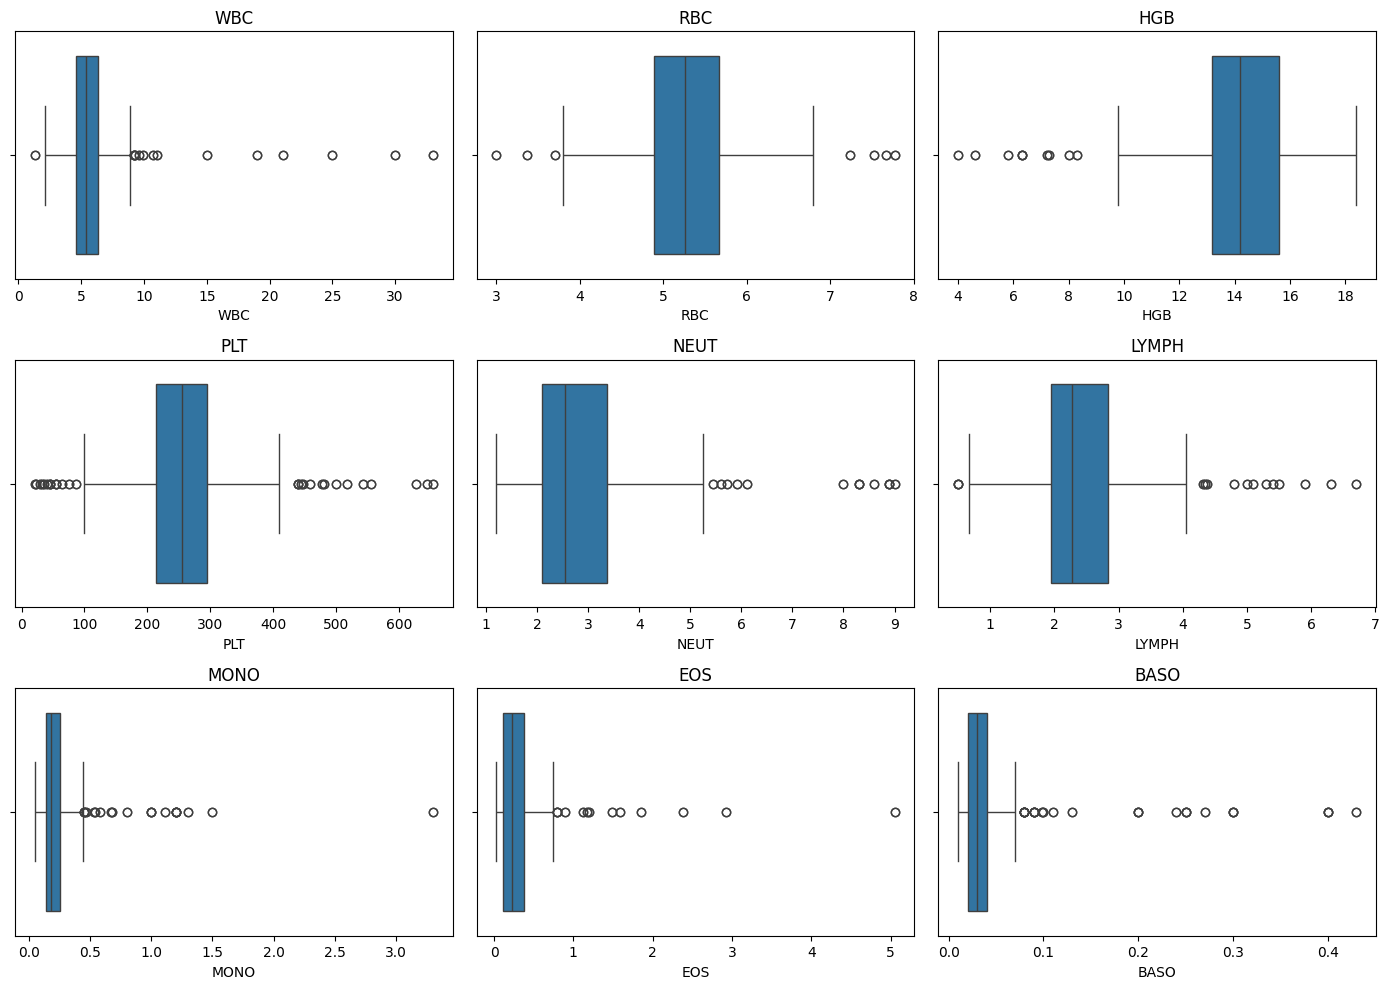

,IQR_flag_count
WBC,28
RBC,14
HGB,18
PLT,54
NEUT,24
LYMPH,28
MONO,36
EOS,24
BASO,44


In [27]:
display(df[expected_features].describe().T)
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for col, ax in zip(expected_features, axes.flat):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

iqr_flags = {}
for col in expected_features:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    iqr_flags[col] = int(((df[col] < low) | (df[col] > high)).sum())
display(pd.Series(iqr_flags, name="IQR_flag_count").to_frame())


## 5. Handle missing values and duplicates
The supplied file currently has no missing values. If missing values are present, median imputation is used for numeric features. Exact duplicate rows are removed; conflicting duplicate feature vectors are surfaced for review. Keep a record of any rows removed.

In [28]:
rows_before = len(df)
# Remove rows with a missing target: a supervised example needs a known label.
df = df.dropna(subset=[target_col]).copy()
# Remove exact duplicates only.
df = df.drop_duplicates().copy()
rows_after = len(df)
print(f"Rows before: {rows_before}; after exact duplicate/target cleanup: {rows_after}")
print("Rows removed:", rows_before - rows_after)

# Preserve missing feature values here; the median imputer in the model pipeline
# is fitted only on training data to avoid data leakage.
X = df[expected_features].copy()
y = df[target_col].astype(int).copy()
print("Feature matrix:", X.shape, "| Target:", y.shape)
print("Remaining missing feature values:", int(X.isna().sum().sum()))


Rows before: 598; after exact duplicate/target cleanup: 299
Rows removed: 299
Feature matrix: (299, 9) | Target: (299,)
Remaining missing feature values: 0


## 6. Encode target meaning and export
The app defines class IDs 0–13. This mapping is copied from the project's `main.py`; verify it against the source dataset documentation before interpreting outputs clinically.

In [29]:
disease_map = {
    0: "Anemia", 1: "Polycythemia", 2: "Leukocytosis", 3: "Leukopenia",
    4: "Thrombocytopenia", 5: "Thrombocytosis", 6: "Neutropenia",
    7: "Neutrophilia", 8: "Lymphocytopenia", 9: "Lymphocytosis",
    10: "Monocytes high", 11: "Eosinophil high", 12: "Basophil high",
    13: "Normal"
}
unknown = set(y.unique()) - set(disease_map)
print("Unknown target IDs:", unknown)
display(y.map(disease_map).value_counts().rename("samples").to_frame())

cleaned = X.copy()
cleaned[target_col] = y
cleaned.to_csv("cleaned_data.csv", index=False)
print("Saved cleaned_data.csv", cleaned.shape)
display(cleaned.head())


Unknown target IDs: set()


,samples
Disease,
Normal,105
Polycythemia,42
Leukopenia,34
Eosinophil high,26
Thrombocytopenia,16
Neutropenia,14
Anemia,11
Thrombocytosis,10
Monocytes high,8


Saved cleaned_data.csv (299, 10)


,WBC,RBC,HGB,PLT,NEUT,LYMPH,MONO,EOS,BASO,Disease
0,3.7,4.90,15.6,275,1.96,1.32,0.17,0.25,0.03,3
1,7.0,5.12,13.5,386,3.33,3.05,0.53,0.09,0.06,13
2,5.0,4.67,13.3,211,2.00,2.09,0.26,0.61,0.03,11
3,6.9,4.80,15.0,224,3.77,1.75,0.58,0.70,0.05,11
4,4.2,5.31,16.0,224,2.18,1.49,0.20,0.29,0.03,3


## What to explain to your teacher
- **Cleaning:** validate schema and types, audit missing/duplicate values, and flag unusual ranges for review.
- **Preprocessing:** separate nine predictors (`X`) from the class label (`y`); keep target labels as integer class IDs.
- **Leakage prevention:** imputation, if required, should be learned from training data only. The next notebook uses a scikit-learn pipeline.
- **Important limitation:** this is a small dataset (299 records), and statistical patterns alone do not establish medical diagnostic validity. Predictions are educational demonstrations, not clinical diagnoses.